# Blurred Atom Examples

This notebook visualizes synthetic blurred-atom configurations built from combined 1-fold, 2-fold, and 3-fold parts.

In [102]:
import math
import torch 
import os
import numpy as np
import sys
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
torch.set_default_dtype(torch.float64)
def make_ngon_structure(n, radius=1.0, angle=0.0,  device=None):
    """
    Regular n-particle structure centered at origin.

    Points:
        z_k = radius * exp(i * (angle + 2*pi*k/n))
    """
    k = torch.arange(n, device=device, dtype=torch.float32)
    angles = angle + 2 * torch.pi * k / n
    z = radius * torch.exp(1j * angles)
    # Convert to cartesian coordinates
    z = torch.stack([z.real, z.imag], dim=-1)
    return z

# Make example structure with 4-fold, 2-fold, and 3-fold components
def get_structure(rot_type4=0.0, rot_type3=0.0):
    type4 = make_ngon_structure(4, radius=16.0, angle=rot_type4)
    type4_clr = [*(["orange"] * type4.shape[0])]
    type3 = make_ngon_structure(3, radius=5.0, angle=rot_type3)
    type3_clr = [*(["green"] * type3.shape[0])]

    structure = torch.cat([type4, type3], dim=0, )
    colors = [*type4_clr, *type3_clr] 
    return structure, colors 

def _flusser_invariants(moments, pq): 
    # using the first type=1 as normalizer
    # check if there is a 1,0 and 0, 0 
    if not torch.is_complex(moments) and (moments.ndim != 2 or moments.shape[1] != 2):
        raise ValueError(f"Expected moments with a complex dtype or shape [M, 2], got {tuple(moments.shape)}")
    moments = moments if torch.is_complex(moments) else torch.view_as_complex(moments)
    if moments.shape[-1] != pq.shape[0]:
        raise ValueError(f"Expected moments with shape [M], got {tuple(moments.shape)}")
    # Note: This can be moved to init and pack this into class.
    vol_idx = np.where((pq == np.array([0,0])).all(axis=1))[0][0]
    norm_idx = np.where((pq == np.array([1,0])).all(axis=1))[0][0]
    orders = pq[:, 0] - pq[:, 1]
    # Normalize by the zero-order moment (intensity sum)
    moments = moments / torch.clamp(moments[..., vol_idx:vol_idx+1].abs(), min=1e-8)
    trivials = moments[..., orders == 0].abs()
    # Normalize by the first-order moment (centroid)
    c10 = moments[..., norm_idx]
    nontrivials_mask = orders != 0
    nontrivials_mask[norm_idx] = False  
    nontrivials = moments[..., nontrivials_mask]
    nontrivials_mag = nontrivials.abs()
    # Calculate magnitudes
    magnitude = torch.sigmoid(c10.abs())
    #magnitude = c10.abs()
    # NOTE: This is not gradient safe
    c10 = c10 ** -orders[nontrivials_mask]
    angle = torch.atan2(c10.imag, c10.real) * -orders[nontrivials_mask]
    _real = magnitude * torch.cos(angle)
    _imag = magnitude * torch.sin(angle)
    real_invariants = _real * nontrivials.real - _imag * nontrivials.imag
    real_invariants = real_invariants / torch.clamp(nontrivials_mag * magnitude, min=1e-5)
    # Normalize the frequncy of real invariants by the magnitude to compensate for different n-fold ambiguities
    
     
    # Compensate for different n-fold ambiguities
    invariants = torch.concat([trivials, nontrivials_mag, real_invariants], dim=-1)
    return trivials, nontrivials_mag, real_invariants

def _compute_complex_moments_2d(
    points: torch.Tensor,
    max_frequency: int,
    *,
    pq: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Compute sparse 2D complex moments from points with shape [..., N, 2].

    Each moment is
        mu_{p,q} = sum_n z_n^p conj(z_n)^q,
    where z_n = x_n + i y_n.
    """
    if points.ndim < 2:
        raise ValueError(f"Expected points with shape [..., N, 2], got {tuple(points.shape)}")
    if points.shape[-1] != 2:
        raise ValueError(f"Expected last dimension to be 2, got {points.shape[-1]}")
    if not torch.is_floating_point(points):
        raise TypeError("points must have a real floating-point dtype")

    if pq is None:
        pq = complex_moment_pq(max_frequency, device=points.device)
    else:
        if pq.ndim != 2 or pq.shape[-1] != 2:
            raise ValueError(f"Expected orders with shape [M, 2], got {tuple(pq.shape)}")
        pq = pq.to(device=points.device, dtype=torch.long)

    z = torch.complex(points[..., 0], points[..., 1])
    z = z.unsqueeze(-1)

    p = pq[:, 0].to(dtype=z.real.dtype)
    q = pq[:, 1].to(dtype=z.real.dtype)

    moments = (z.pow(p) * z.conj().pow(q)).sum(dim=-2)
    return moments

def _complex_moment_pq(max_frequency: int, *, device: Optional[torch.device] = None) -> torch.Tensor:
    """Return all (p, q) with p >= q >= 0 and p + q <= max_frequency."""
    if max_frequency < 0:
        raise ValueError("max_frequency must be non-negative")

    orders = [
        (p, q)
        for total_degree in range(max_frequency + 1)
        for q in range(total_degree // 2 + 1)
        for p in [total_degree - q]
    ]
    return torch.tensor(orders, dtype=torch.long, device=device)


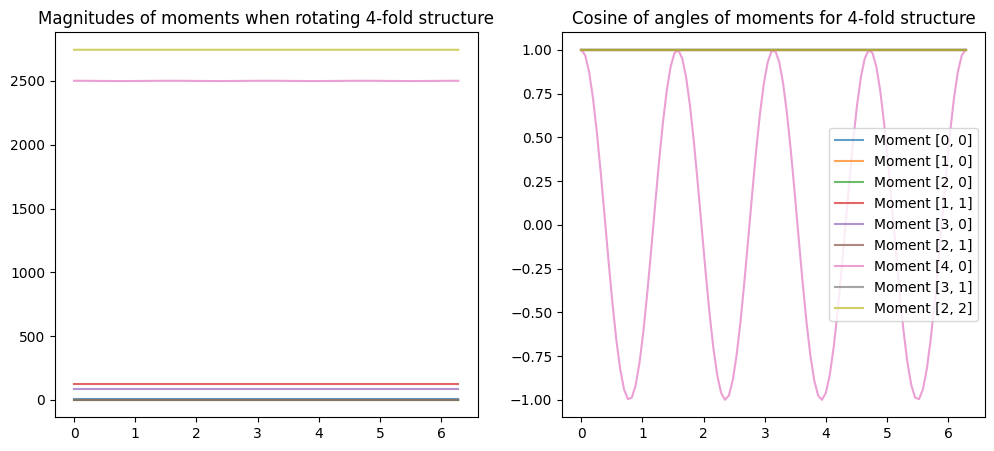

In [ ]:
# angles for the 2-fold structure should be periodic with period pi, and the magnitudes should be constant.
# calculate moments 
max_freq = 4
fixed_nfold = 1
nfold = 4
radius = 5

fixed_structures = [make_ngon_structure(fixed_nfold, radius=1.0, angle=0.0), make_ngon_structure(3, radius=3.0, angle=0.0)]
pq = _complex_moment_pq(max_freq)
angles = torch.linspace(0, 2 * torch.pi, steps=100)
mag = []
phase = []

trivials, nontrivials_mag, real_invariants = [], [], []
for angle in angles:
     n = make_ngon_structure(nfold, radius=
                             radius, angle=angle)
     structure = torch.cat([*fixed_structures, n], dim=0)
     moments = _compute_complex_moments_2d(structure.unsqueeze(0), max_freq, pq=pq)
     mag.append(moments.abs())
     phase.append(moments.angle())
     _trivials, _nontrivials_mag, _real_invariants = _flusser_invariants(moments, pq)
     trivials.append(_trivials)
     nontrivials_mag.append(_nontrivials_mag)
     real_invariants.append(_real_invariants)

orders = pq[:, 0] - pq[:, 1]

# Plot all the moments 

#plt.plot(angles, mag[:, 0], label="Magnitude")
mag = torch.concat(mag)
phase = torch.concat(phase)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(mag.shape[1]):
    axes[0].plot(angles, mag[:, idx], alpha=0.7, label=f"Moment {pq[idx].tolist()}")
    # kicked out the phase with small magnitudes
    mag_mask = mag[:, idx] > 1e-1
    axes[1].plot(angles, torch.cos( phase[:, idx] * mag_mask), alpha=0.7, label=f"Moment {pq[idx].tolist()}")
axes[0].set_title("Magnitudes of moments when rotating 4-fold structure")
axes[1].set_title("Cosine of angles of moments for 4-fold structure")
plt.legend()

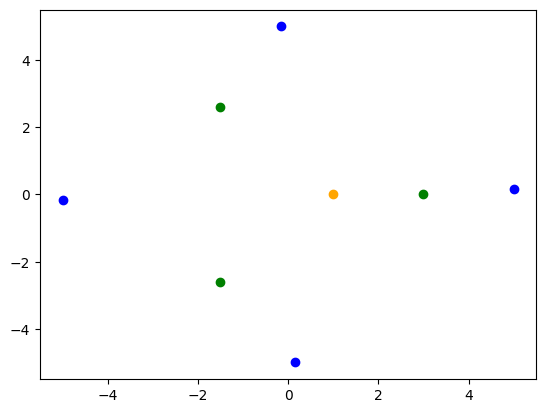

In [97]:
# Plot the starting structure and middle rotation 
from turtle import color


plt.scatter(*fixed_structures[0].T, label="Fixed 1-fold", color="orange")
plt.scatter(*fixed_structures[1].T, label="Fixed 3-fold", color="green")
plt.scatter(*make_ngon_structure(nfold, radius=radius, angle=angles[len(angles) // 2]).T, label="Rotating 4-fold", color="blue")

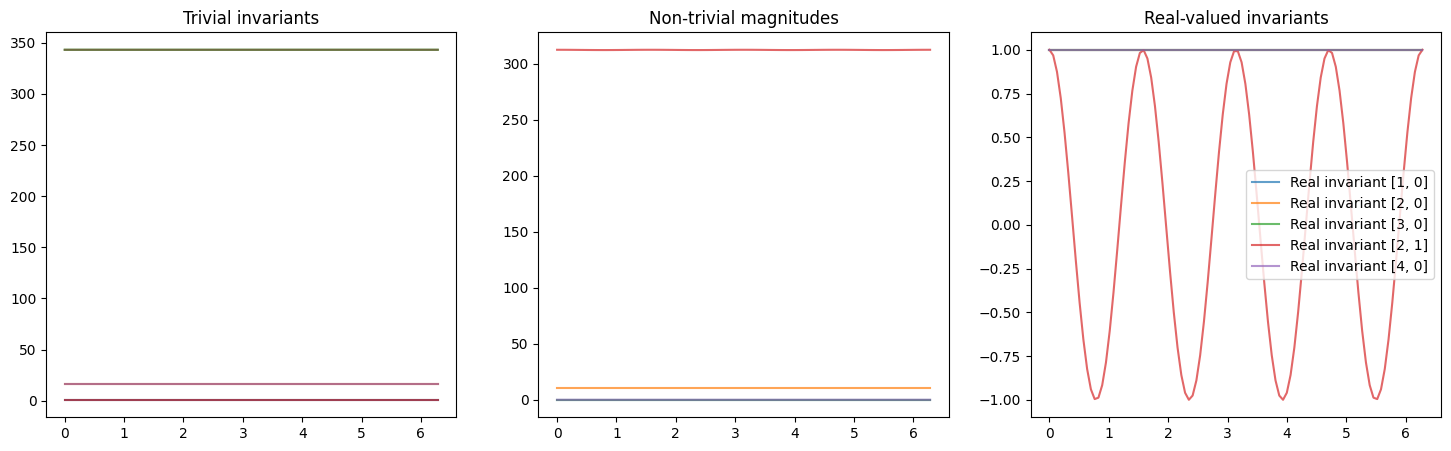

In [98]:
# plot trivials, nontrivials_mag, and real_invariants separately
def plot_invariants(angles, trivials, nontrivials_mag, real_invariants, pq):
    trivials_t = torch.concat(trivials, dim=0)
    nontrivials_mag_t = torch.concat(nontrivials_mag, dim=0)
    real_invariants_t = torch.concat(real_invariants, dim=0)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(angles, trivials_t, label="Trivial invariants")
    for idx in range(trivials_t.shape[1]):
        axes[0].plot(angles, trivials_t[:, idx], alpha=0.7, label=f"Trivial invariant {idx}")
    axes[0].set_title("Trivial invariants")
    for idx in range(nontrivials_mag_t.shape[1]):
        axes[1].plot(angles, nontrivials_mag_t[:, idx], alpha=0.7, label=f"Non-trivial mag {pq[orders!=0][idx].tolist()}")
    axes[1].set_title("Non-trivial magnitudes")
    for idx in range(real_invariants_t.shape[1]):
        axes[2].plot(angles, real_invariants_t[:, idx], alpha=0.7, label=f"Real invariant {pq[orders!=0][idx].tolist()}")
    axes[2].set_title("Real-valued invariants")
    plt.legend()    
plot_invariants(angles, trivials, nontrivials_mag, real_invariants, pq)

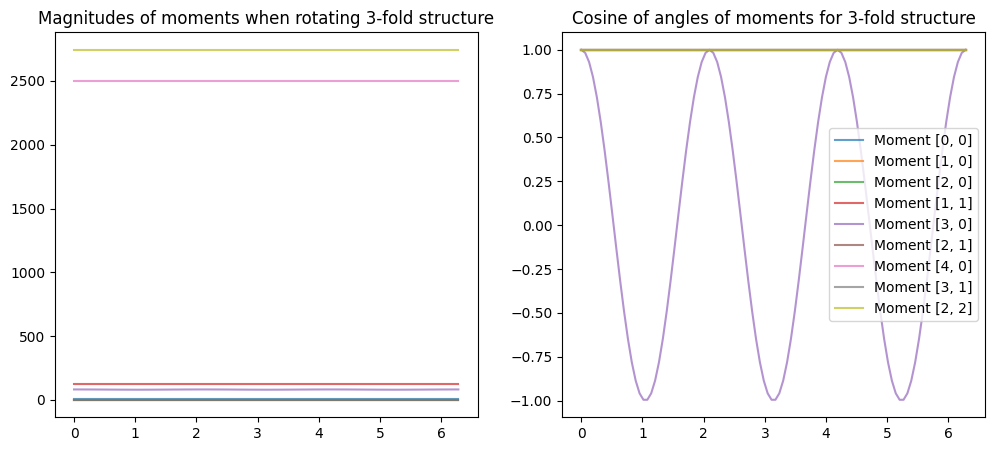

In [99]:
# angles for the 2-fold structure should be periodic with period pi, and the magnitudes should be constant.
# calculate moments 
max_freq = 4
fixed_nfold = 1
nfold = 3
radius = 3

fixed_structures = [make_ngon_structure(fixed_nfold, radius=1.0, angle=0.0), make_ngon_structure(4, radius=5.0, angle=0.0)]
pq = _complex_moment_pq(max_freq)
angles = torch.linspace(0, 2 * torch.pi, steps=100)
mag = []
phase = []

trivials, nontrivials_mag, real_invariants = [], [], []
for angle in angles:
     n = make_ngon_structure(nfold, radius=
                             radius, angle=angle)
     structure = torch.cat([*fixed_structures, n], dim=0)
     moments = _compute_complex_moments_2d(structure.unsqueeze(0), max_freq, pq=pq)
     mag.append(moments.abs())
     phase.append(moments.angle())
     _trivials, _nontrivials_mag, _real_invariants = _flusser_invariants(moments, pq)
     trivials.append(_trivials)
     nontrivials_mag.append(_nontrivials_mag)
     real_invariants.append(_real_invariants)

orders = pq[:, 0] - pq[:, 1]

# Plot all the moments 

#plt.plot(angles, mag[:, 0], label="Magnitude")
mag = torch.concat(mag)
phase = torch.concat(phase)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(mag.shape[1]):
    axes[0].plot(angles, mag[:, idx], alpha=0.7, label=f"Moment {pq[idx].tolist()}")
    # kicked out the phase with small magnitudes
    mag_mask = mag[:, idx] > 1e-1
    axes[1].plot(angles, torch.cos( phase[:, idx] * mag_mask), alpha=0.7, label=f"Moment {pq[idx].tolist()}")
axes[0].set_title("Magnitudes of moments when rotating 3-fold structure")
axes[1].set_title("Cosine of angles of moments for 3-fold structure")
plt.legend()

In [24]:
plot_invariants(angles, trivials, nontrivials_mag, real_invariants, pq)

ValueError: torch.cat(): expected a non-empty list of Tensors

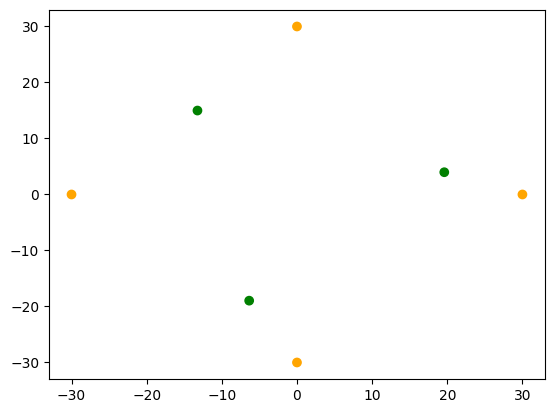

In [100]:
import torch 
# Create an artificial dataset to test flexibility 

fold4 = make_ngon_structure(4, radius=30, angle=0)
fold3 = make_ngon_structure(3, radius=20, angle=0.2)  

colors = ["orange"] * fold4.shape[0] + ["green"] * fold3.shape[0]

points = torch.cat([fold4, fold3], dim=0)

plt.scatter(*points.T, color=colors)

# Calculate distance to nearest point 


Number of positive examples: 0
Number of negative examples: 360


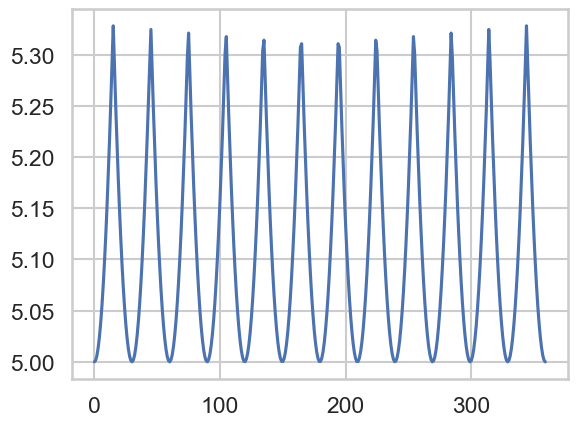

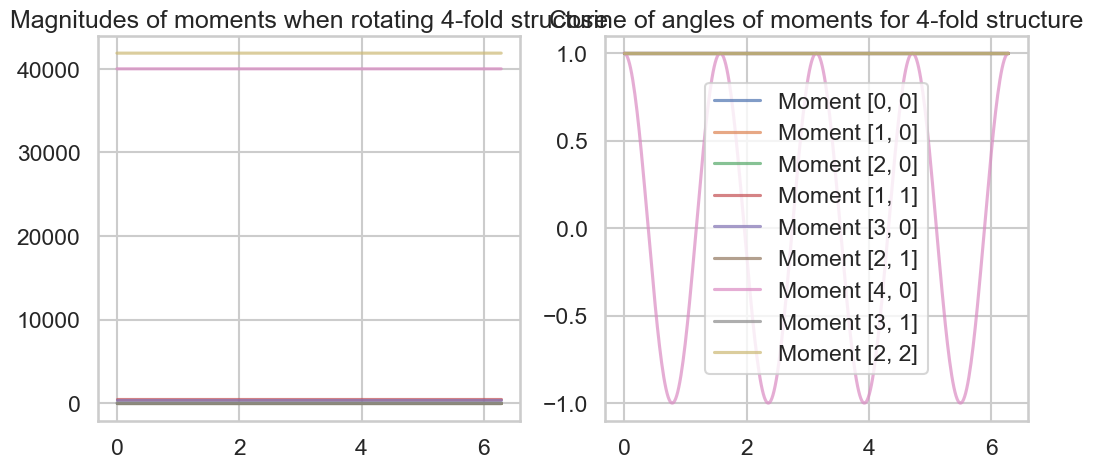

In [130]:
# Create an adversial flexible example 
# * different distance between points 4-fold and 3-fold 
# * and maybe 1-fold, 4-fold and 3-fold 
# Single big convolution with circles as points 
#  
# Create four groups with random rotations. 
# Check what the instance norm one do to orders 
# Can we do an order and phase norm?? 
configurations = []
labels = []
mag = []
phase = []
radius_3fold = 5
radius_4fold = 10

fold3 = make_ngon_structure(3, radius=radius_3fold, angle=0)  
min_dists = []
max_freq = 4
pq = _complex_moment_pq(max_freq)
angles = torch.linspace(0, 2 * torch.pi, steps=360)

for angle in angles:
    fold4 = make_ngon_structure(4, radius=radius_4fold, angle=angle)
    # Calculate pairwise distances between points in fold4 and fold3
    dists = torch.cdist(fold4, fold3)
    min_dist = dists.min()
    if min_dist < 10.15:
        labels.append(False)
    else:        
        labels.append(True)
    min_dists.append(min_dist)
    configurations.append(torch.cat([fold4, fold3], dim=0))
    moments = _compute_complex_moments_2d(configurations[-1].unsqueeze(0), max_freq, pq=pq)
    mag.append(moments.abs())
    phase.append(moments.angle())

# Count labels
labels = torch.tensor(labels)
print(f"Number of positive examples: {labels.sum().item()}")
print(f"Number of negative examples: {(~labels).sum().item()}")
configurations = torch.stack(configurations, dim=0)
plt.plot(min_dists)

# Plot moments 
mag = torch.concat(mag)
phase = torch.concat(phase)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(mag.shape[1]):
    axes[0].plot(angles, mag[:, idx], alpha=0.7, label=f"Moment {pq[idx].tolist()}")
    # kicked out the phase with small magnitudes
    mag_mask = mag[:, idx] > 5e-1
    axes[1].plot(angles, torch.cos( phase[:, idx] * mag_mask), alpha=0.7, label=f"Moment {pq[idx].tolist()}")
axes[0].set_title("Magnitudes of moments when rotating 4-fold structure")
axes[1].set_title("Cosine of angles of moments for 4-fold structure")
plt.legend()

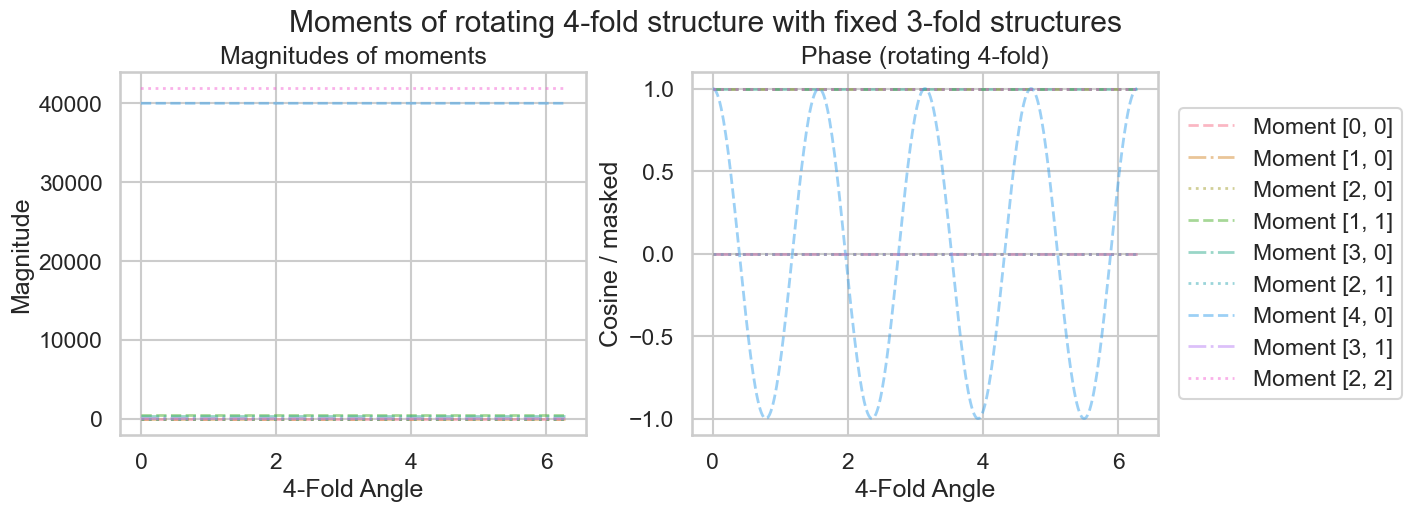

In [131]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
mask_threshold = 5e-1

n = mag.shape[1]
palette = sns.color_palette("husl", n)
linestyles = [ "--", "-.", ":"]
# Rotate the styles 
chosen_styles = [random.choice(linestyles) for _ in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for idx in range(n):
    color = palette[idx]
    ls = linestyles[idx % len(linestyles)]
    label = f"Moment {pq[idx].tolist()}"

    axes[0].plot(
        angles,
        mag[:, idx],
        color=color,
        linestyle=ls,
        linewidth=2,
        alpha=0.5,
        label=label,
    )

    mag_mask = mag[:, idx] > mask_threshold
    axes[1].plot(
        angles,
        torch.cos(phase[:, idx]) * mag_mask,
        color=color,
        linestyle=ls,
        linewidth=2,
        alpha=0.5,
        label=label,
    )

axes[0].set_title("Magnitudes of moments")
axes[1].set_title("Phase (rotating 4-fold)")

axes[0].set_xlabel("4-Fold Angle")
axes[1].set_xlabel("4-Fold Angle")

axes[0].set_ylabel("Magnitude")
axes[1].set_ylabel("Cosine / masked")

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
fig.suptitle("Moments of rotating 4-fold structure with fixed 3-fold structures")
plt.show()


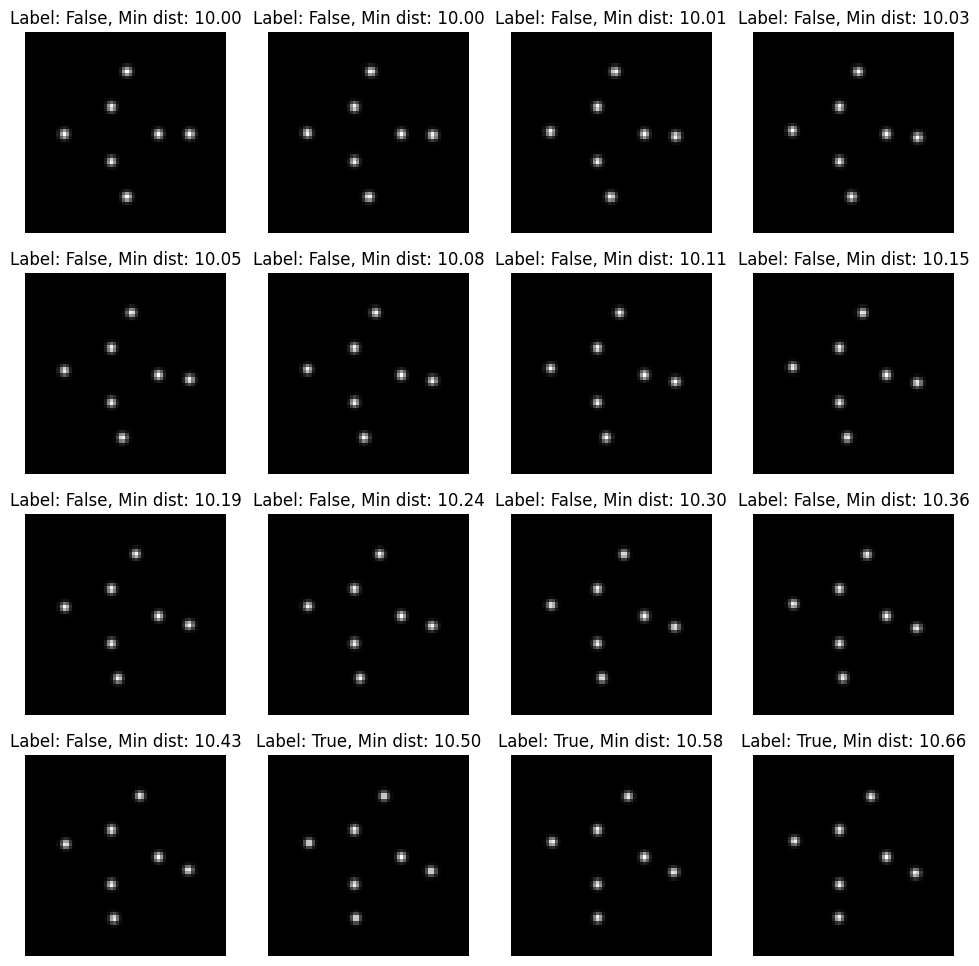

In [74]:
from hippy2d.utils import rasterize_point_configurations

rasterized_configurations = rasterize_point_configurations(configurations, grid_size=64, sigma=1.0)

# plot first 16 
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(rasterized_configurations[idx].cpu(), cmap="gray")
    ax.set_title(f"Label: {labels[idx].item()}, Min dist: {min_dists[idx]:.2f}")
    ax.axis("off")

In [80]:
# Save artificial dataset to a folder
path = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/data/flexds"
os.makedirs(path, exist_ok=True)
os.makedirs(os.path.join(path, "dist<10.15"), exist_ok=True)
os.makedirs(os.path.join(path, "dist>=10.15"), exist_ok=True)
# Save it as png, distance in the name of the file
for idx in range(configurations.shape[0]):
    label = "dist<10.15" if min_dists[idx] < 10.15 else "dist>=10.15"
    plt.imsave(os.path.join(path, label, f"config_{idx}_dist_{min_dists[idx]:.2f}.png"), rasterized_configurations[idx].cpu(), cmap="gray")

In [115]:
chosen_styles

['-.', '-.', '-.', '--', '--', '--', '-.', '-.', '-.']